# Fake News Classifier – NLP Group Project
## Ironhack Data Science Bootcamp

This notebook is the **final merged deliverable** for our group NLP project. It brings together the individual model analyses from all three team members into a single end-to-end pipeline, and extends the comparison with a state-of-the-art **Transformer model (ELECTRA Small)**.

---

### Objective

Build a binary text classifier that distinguishes **fake (0)** from **real (1)** news headlines, then generate predictions for an unseen test set in the original file format.

---

### Dataset

- **Source:** Tab-separated CSV provided by Ironhack (Kaggle-derived fake news detection dataset)
- **Training rows:** 34,152 raw → 32,202 after deduplication and cleaning
- **Test rows:** 9,984
- **Labels:** `0` = Fake, `1` = Real, `2` = placeholder in test file

---

### Team

| Member | GitHub | Models |
|---|---|---|
| **Irish Levi** | [@irish16levi](https://github.com/irish16levi) | Logistic Regression · Linear SVM · Sentence Embeddings |
| **Gregori** | [@Greg2828](https://github.com/Greg2828) | Multinomial Naive Bayes |
| **Juan Alvaro** | [@juanalvaroromero-cell](https://github.com/juanalvaroromero-cell) | Random Forest · XGBoost · ELECTRA Transformer |

---

### Notebook Contents

| Section | Description |
|---|---|
| **1** | Imports & Setup |
| **2** | Load Data |
| **3** | Exploratory Data Analysis |
| **4** | Text Preprocessing (deduplication, lowercasing, stopword removal, Porter stemming) |
| **5** | Train / Validation Split (80/20, stratified, `random_state=42`) |
| **6** | Vectorization Strategy (BoW and TF-IDF per model family) |
| **7** | Train All Baseline Models (LR, SVM, NB, RF, XGBoost × BoW/TF-IDF) |
| **8** | Combined Model Comparison |
| **9** | Hyperparameter Tuning (GridSearchCV with Pipeline) |
| **10** | Final Best Model Selection |
| **11** | Detailed Evaluation (classification report, confusion matrix) |
| **12** | Cross-Validation (5-fold) |
| **13** | Feature Interpretation (top discriminating tokens) |
| **14** | Error Analysis (misclassified headlines) |
| **15** | Retrain on Full Training Dataset |
| **16** | Generate Test Predictions |
| **17** | Save Prediction File |
| **18** | Final Conclusion |
| **19** | ELECTRA Small Transformer (results + reproducible training code) |
| **20** | Updated Final Conclusion After ELECTRA |

---

### Key Results

| Model | Vectorizer | Validation Accuracy |
|---|---|---|
| **ELECTRA Small** *(Transformer)* | ELECTRA tokenizer | **0.9778** |
| Linear SVM | TF-IDF | 0.9362 |
| Logistic Regression | TF-IDF | 0.9340 |
| Naive Bayes | Bag of Words | 0.9306 |
| XGBoost | Bag of Words | 0.9244 |
| Random Forest | TF-IDF | 0.9188 |

> **Classical models** run locally using a Python virtual environment.  
> **ELECTRA** was fine-tuned on Google Colab Pro (A100 GPU). Set `RUN_ELECTRA_TRAINING = True` in Section 19 to retrain.

## 1. Imports & Setup


In [ ]:
import os
import re
import math
import string
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost is not installed. XGBoost models will be skipped.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FAST_MODE = False

RF_ESTIMATORS = 200 if FAST_MODE else 1000
XGB_ESTIMATORS = 300 if FAST_MODE else 1500
XGB_TUNING_ESTIMATORS = 120 if FAST_MODE else 400

RUN_EXPENSIVE_XGB_GRID = False

sns.set_theme(style="whitegrid")
print("Setup complete.")


Setup complete.


In [23]:
!pip install transformers datasets -q
print('Packages ready.')

Packages ready.


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load Data


In [27]:
from pathlib import Path

# Define the base path to your dataset directory in Google Drive
gdrive_dataset_path = Path("/content/drive/MyDrive/Colab Notebooks/project-3-nlp/dataset/")

# Check if the directory exists and list its contents
if gdrive_dataset_path.exists():
    print(f"Contents of {gdrive_dataset_path}:")
    for item in gdrive_dataset_path.iterdir():
        print(f"- {item.name}")
else:
    print(f"The directory {gdrive_dataset_path} does not exist. Please ensure your files are in this exact location in your Google Drive.")
    print("If the folder exists but is empty, please upload your 'training_data.csv' and 'testing_data.csv' files into it.")

Contents of /content/drive/MyDrive/Colab Notebooks/project-3-nlp/dataset:
- testing_data.csv
- test_clean.csv
- training_data.csv
- train_clean.csv


In [28]:
from pathlib import Path
import pandas as pd

# Create the dataset directory if it doesn't exist
Path("dataset").mkdir(exist_ok=True)

# Re-defining the variables and functions from the original cell 19d7a8dd
# Store file paths as variables so they are easy to change in one place
TRAIN_CANDIDATES = [
    "/content/drive/MyDrive/Colab Notebooks/project-3-nlp/dataset/training_data.csv",
    "dataset/training_data.csv",
    "/content/drive/MyDrive/Colab Notebooks/project-3-nlp/dataset/training.csv",
    "dataset/training.csv",
    "training_data.csv",
    "training.csv",
]

TEST_CANDIDATES = [
    "/content/drive/MyDrive/Colab Notebooks/project-3-nlp/dataset/testing_data.csv",
    "dataset/testing_data.csv",
    "/content/drive/MyDrive/Colab Notebooks/project-3-nlp/dataset/testing.csv",
    "dataset/testing.csv",
    "testing_data.csv",
    "testing.csv",
]

def find_existing_path(candidates):
    for path in candidates:
        if Path(path).exists():
            return path
    raise FileNotFoundError(
        "None of these files were found:\n" + "\n".join(candidates)
    )

TRAIN_PATH = find_existing_path(TRAIN_CANDIDATES)
TEST_PATH = find_existing_path(TEST_CANDIDATES)

print(f"Training file: {TRAIN_PATH}")
print(f"Testing file : {TEST_PATH}")

def load_project_file(path):
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["label", "text"],
        encoding="utf-8-sig",
    )
    return df

train_df = load_project_file(TRAIN_PATH)
test_df = load_project_file(TEST_PATH)

train_df["label"] = (
    train_df["label"]
    .astype(str)
    .str.replace("\ufeff", "", regex=False)
    .astype(int)
)

test_df["label"] = 2

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows : {len(test_df):,}")
display(train_df.head())

Training file: /content/drive/MyDrive/Colab Notebooks/project-3-nlp/dataset/training_data.csv
Testing file : /content/drive/MyDrive/Colab Notebooks/project-3-nlp/dataset/testing_data.csv
Training rows: 34,152
Testing rows : 9,984


,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


The files loaded correctly and the first rows look like the expected format: one column for the label and one column for the headline. In the test file the labels are only placeholders, so later we replace them with our predictions.


## 3. Exploratory Data Analysis


In [29]:
print("=== Training data info ===")
print(train_df.info())

print("\nNull values:")
print(train_df.isnull().sum())

print("\nDuplicate check:")
dup_full = train_df.duplicated().sum()
dup_text = train_df["text"].duplicated().sum()

print(f"Fully duplicate rows              : {dup_full:,}")
print(f"Duplicate headlines by text only  : {dup_text:,}")

if dup_text > 0:
    dup_mask = train_df["text"].duplicated(keep=False)
    print("\nSample duplicate headlines:")
    display(train_df[dup_mask].sort_values("text")[["label", "text"]].head(8))


=== Training data info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34152 entries, 0 to 34151
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   34152 non-null  int64 
 1   text    34152 non-null  object
dtypes: int64(1), object(1)
memory usage: 533.8+ KB
None

Null values:
label    0
text     0
dtype: int64

Duplicate check:
Fully duplicate rows              : 1,946
Duplicate headlines by text only  : 1,946

Sample duplicate headlines:


,label,text
32603,1,'can i get it to go?' canada's trudeau charms ...
18246,1,'can i get it to go?' canada's trudeau charms ...
30041,1,'fierce and formidable' dlamini-zuma eyes sout...
29698,1,'fierce and formidable' dlamini-zuma eyes sout...
18400,1,'he's such a dreamer:' skepticism dogs u.s. en...
33291,1,'he's such a dreamer:' skepticism dogs u.s. en...
22011,1,'nuclear option' fallout? more extreme u.s. ju...
22007,1,'nuclear option' fallout? more extreme u.s. ju...


There are no missing values, which makes the cleaning part easier. We found duplicated headlines in the training set, so removing them makes sense because otherwise the model could learn repeated examples too much.


Label counts:
label
Fake (0)    17572
Real (1)    16580
Name: count, dtype: int64


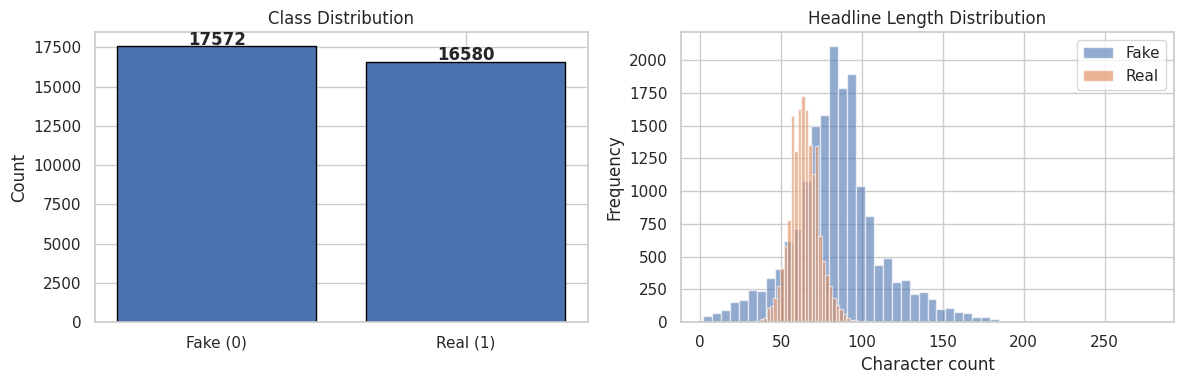


Average headline length – Fake: 84.6 chars
Average headline length – Real: 64.2 chars


In [30]:
label_counts = train_df["label"].value_counts().sort_index()
print("Label counts:")
print(label_counts.rename({0: "Fake (0)", 1: "Real (1)"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    ["Fake (0)", "Real (1)"],
    label_counts.values,
    edgecolor="black",
)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

train_df["text_len"] = train_df["text"].astype(str).str.len()

for label, name in [(0, "Fake"), (1, "Real")]:
    subset = train_df[train_df["label"] == label]["text_len"]
    axes[1].hist(subset, bins=50, alpha=0.6, label=name)

axes[1].set_title("Headline Length Distribution")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nAverage headline length – Fake: {train_df[train_df['label']==0]['text_len'].mean():.1f} chars")
print(f"Average headline length – Real: {train_df[train_df['label']==1]['text_len'].mean():.1f} chars")


The dataset is quite balanced. There are a little more fake headlines than real ones, but the difference is not big, so accuracy is still a useful metric here. Fake headlines are also longer on average, which is an interesting pattern but not enough by itself to classify the news.


## 4. Text Preprocessing


In [31]:
try:
    STOP_WORDS = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    STOP_WORDS = set(stopwords.words("english"))

stemmer = PorterStemmer()

def preprocess(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = text.split()

    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in STOP_WORDS and len(token) > 1
    ]

    return " ".join(tokens)

before_train = len(train_df)
train_df = train_df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
duplicates_removed = before_train - len(train_df)

test_duplicates = test_df["text"].duplicated().sum()

train_df = train_df[
    train_df["text"].notna() & train_df["text"].astype(str).str.strip().ne("")
].reset_index(drop=True)

test_df = test_df[
    test_df["text"].notna() & test_df["text"].astype(str).str.strip().ne("")
].reset_index(drop=True)

train_df["clean_text"] = train_df["text"].apply(preprocess)
test_df["clean_text"] = test_df["text"].apply(preprocess)

before_empty = len(train_df)
train_df = train_df[train_df["clean_text"].str.strip().ne("")].reset_index(drop=True)
empty_removed = before_empty - len(train_df)

test_df["clean_text"] = test_df["clean_text"].fillna("")

print(f"Training duplicates removed : {duplicates_removed:,}")
print(f"Test duplicate headlines     : {test_duplicates:,} kept")
print(f"Empty clean_text rows removed: {empty_removed:,}")
print(f"Final training rows          : {len(train_df):,}")
print(f"Final testing rows           : {len(test_df):,}")

print("\nExample before preprocessing:")
print(train_df["text"].iloc[0])
print("\nExample after preprocessing:")
print(train_df["clean_text"].iloc[0])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Training duplicates removed : 1,946
Test duplicate headlines     : 776 kept
Empty clean_text rows removed: 4
Final training rows          : 32,202
Final testing rows           : 9,984

Example before preprocessing:
donald trump sends out embarrassing new year‚s eve message; this is disturbing

Example after preprocessing:
donald trump send embarrass new year eve messag disturb


After cleaning, the text looks less natural but more useful for the model. For example, words are lowercase, punctuation disappears and similar words are reduced to a simpler form. We kept all test rows because the final file must have the same number of rows as the original test file.


In [32]:
Path("dataset").mkdir(exist_ok=True)

TRAIN_CLEAN_PATH = "dataset/train_clean.csv"
TEST_CLEAN_PATH = "dataset/test_clean.csv"

train_df[["label", "text", "clean_text"]].to_csv(TRAIN_CLEAN_PATH, index=False)
test_df[["label", "text", "clean_text"]].to_csv(TEST_CLEAN_PATH, index=False)

print(f"Saved: {TRAIN_CLEAN_PATH}")
print(f"Saved: {TEST_CLEAN_PATH}")


Saved: dataset/train_clean.csv
Saved: dataset/test_clean.csv


## 5. Train / Validation Split


In [33]:
train_clean_df = pd.read_csv(TRAIN_CLEAN_PATH)
test_clean_df = pd.read_csv(TEST_CLEAN_PATH)

train_clean_df["clean_text"] = train_clean_df["clean_text"].fillna("")
test_clean_df["clean_text"] = test_clean_df["clean_text"].fillna("")

train_part, val_part = train_test_split(
    train_clean_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_clean_df["label"],
)

X_train = train_part["clean_text"]
y_train = train_part["label"]

X_val = val_part["clean_text"]
y_val = val_part["label"]

X_full = train_clean_df["clean_text"]
y_full = train_clean_df["label"]

print(f"Train size: {len(X_train):,}")
print(f"Val size  : {len(X_val):,}")
print(f"Full data : {len(X_full):,}")

print("\nClass balance in train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nClass balance in validation:")
print(y_val.value_counts(normalize=True).sort_index().round(3))


Train size: 25,761
Val size  : 6,441
Full data : 32,202

Class balance in train:
label
0    0.498
1    0.502
Name: proportion, dtype: float64

Class balance in validation:
label
0    0.497
1    0.503
Name: proportion, dtype: float64


The train and validation split keeps almost the same class balance in both parts. This is good because the validation score should be fair and not depend on one class appearing much more than the other.


## 6. Vectorization Strategy


In [34]:
def build_vectorizer(vectorizer_type, config_name):
    if config_name == "linear_nb":
        if vectorizer_type == "bow":
            return CountVectorizer(
                max_features=50_000,
                ngram_range=(1, 2),
                min_df=2,
            )
        if vectorizer_type == "tfidf":
            return TfidfVectorizer(
                max_features=50_000,
                ngram_range=(1, 2),
                sublinear_tf=True,
                min_df=2,
            )

    if config_name == "tree":
        if vectorizer_type == "bow":
            return CountVectorizer(
                max_features=50_000,
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.9,
                binary=True,
            )
        if vectorizer_type == "tfidf":
            return TfidfVectorizer(
                max_features=50_000,
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.9,
                norm="l2",
            )

    raise ValueError(f"Unknown vectorizer_type={vectorizer_type}, config_name={config_name}")

def get_model_definitions():
    model_defs = [
        {
            "member": "Irish Levi",
            "model_name": "Logistic Regression",
            "config": "linear_nb",
            "estimator": LogisticRegression(max_iter=2000, C=5, random_state=RANDOM_STATE),
        },
        {
            "member": "Irish Levi",
            "model_name": "Linear SVM",
            "config": "linear_nb",
            "estimator": LinearSVC(max_iter=5000, C=1.0, random_state=RANDOM_STATE),
        },
        {
            "member": "Gregori",
            "model_name": "Naive Bayes",
            "config": "linear_nb",
            "estimator": MultinomialNB(alpha=0.1),
        },
        {
            "member": "Juan Alvaro",
            "model_name": "Random Forest",
            "config": "tree",
            "estimator": RandomForestClassifier(
                n_estimators=RF_ESTIMATORS,
                n_jobs=-1,
                random_state=RANDOM_STATE,
                max_features="log2",
                min_samples_leaf=2,
            ),
        },
    ]

    if HAS_XGBOOST:
        model_defs.append(
            {
                "member": "Juan Alvaro",
                "model_name": "XGBoost",
                "config": "tree",
                "estimator": XGBClassifier(
                    n_estimators=XGB_ESTIMATORS,
                    tree_method="hist",
                    eval_metric="logloss",
                    verbosity=0,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            }
        )

    return model_defs

model_definitions = get_model_definitions()

print("Models included:")
for item in model_definitions:
    print(f"- {item['member']}: {item['model_name']}")


Models included:
- Irish Levi: Logistic Regression
- Irish Levi: Linear SVM
- Gregori: Naive Bayes
- Juan Alvaro: Random Forest
- Juan Alvaro: XGBoost


Here we put together the models from the three notebooks. The idea is to run all of them with similar vectorizers so the comparison is easier to read.


## 7. Train All Baseline Models


In [35]:
baseline_records = []
fitted_pipelines = {}

def evaluate_pipeline(member, model_name, vectorizer_name, vectorizer, estimator):
    key = f"{model_name} | {vectorizer_name}"

    pipe = Pipeline([
        ("vectorizer", vectorizer),
        ("clf", estimator),
    ])

    pipe.fit(X_train, y_train)
    val_preds = pipe.predict(X_val)
    acc = accuracy_score(y_val, val_preds)

    fitted_pipelines[key] = pipe

    return {
        "Member": member,
        "Model": model_name,
        "Vectorizer": vectorizer_name,
        "Validation Accuracy": acc,
        "Pipeline Key": key,
    }

for model_def in model_definitions:
    for vectorizer_type, vectorizer_label in [
        ("bow", "Bag of Words"),
        ("tfidf", "TF-IDF"),
    ]:
        print(f"Training {model_def['model_name']} with {vectorizer_label}...")
        record = evaluate_pipeline(
            member=model_def["member"],
            model_name=model_def["model_name"],
            vectorizer_name=vectorizer_label,
            vectorizer=build_vectorizer(vectorizer_type, model_def["config"]),
            estimator=clone(model_def["estimator"]),
        )
        baseline_records.append(record)
        print(f"  Validation accuracy: {record['Validation Accuracy']:.4f}")

baseline_results_df = (
    pd.DataFrame(baseline_records)
    .sort_values("Validation Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(baseline_results_df)


Training Logistic Regression with Bag of Words...
  Validation accuracy: 0.9318
Training Logistic Regression with TF-IDF...
  Validation accuracy: 0.9340
Training Linear SVM with Bag of Words...
  Validation accuracy: 0.9233
Training Linear SVM with TF-IDF...
  Validation accuracy: 0.9362
Training Naive Bayes with Bag of Words...
  Validation accuracy: 0.9306
Training Naive Bayes with TF-IDF...
  Validation accuracy: 0.9278
Training Random Forest with Bag of Words...
  Validation accuracy: 0.9182
Training Random Forest with TF-IDF...
  Validation accuracy: 0.9188
Training XGBoost with Bag of Words...
  Validation accuracy: 0.9244
Training XGBoost with TF-IDF...
  Validation accuracy: 0.9214


,Member,Model,Vectorizer,Validation Accuracy,Pipeline Key
0,Irish Levi,Linear SVM,TF-IDF,0.936190,Linear SVM | TF-IDF
1,Irish Levi,Logistic Regression,TF-IDF,0.934016,Logistic Regression | TF-IDF
2,Irish Levi,Logistic Regression,Bag of Words,0.931843,Logistic Regression | Bag of Words
3,Gregori,Naive Bayes,Bag of Words,0.930601,Naive Bayes | Bag of Words
4,Gregori,Naive Bayes,TF-IDF,0.927806,Naive Bayes | TF-IDF
5,Juan Alvaro,XGBoost,Bag of Words,0.924391,XGBoost | Bag of Words
6,Irish Levi,Linear SVM,Bag of Words,0.923304,Linear SVM | Bag of Words
7,Juan Alvaro,XGBoost,TF-IDF,0.921441,XGBoost | TF-IDF
8,Juan Alvaro,Random Forest,TF-IDF,0.918801,Random Forest | TF-IDF
9,Juan Alvaro,Random Forest,Bag of Words,0.918180,Random Forest | Bag of Words


The first comparison shows that the text models work very well. Linear SVM with TF-IDF is the best baseline with around 93.6 percent accuracy, and Logistic Regression and Naive Bayes are very close too. Random Forest and XGBoost worked, but in this case they did not beat the simpler linear models.


## 8. Combined Model Comparison


Combined baseline model comparison:


,Member,Model,Vectorizer,Validation Accuracy,Pipeline Key
0,Irish Levi,Linear SVM,TF-IDF,0.936190,Linear SVM | TF-IDF
1,Irish Levi,Logistic Regression,TF-IDF,0.934016,Logistic Regression | TF-IDF
2,Irish Levi,Logistic Regression,Bag of Words,0.931843,Logistic Regression | Bag of Words
3,Gregori,Naive Bayes,Bag of Words,0.930601,Naive Bayes | Bag of Words
4,Gregori,Naive Bayes,TF-IDF,0.927806,Naive Bayes | TF-IDF
5,Juan Alvaro,XGBoost,Bag of Words,0.924391,XGBoost | Bag of Words
6,Irish Levi,Linear SVM,Bag of Words,0.923304,Linear SVM | Bag of Words
7,Juan Alvaro,XGBoost,TF-IDF,0.921441,XGBoost | TF-IDF
8,Juan Alvaro,Random Forest,TF-IDF,0.918801,Random Forest | TF-IDF
9,Juan Alvaro,Random Forest,Bag of Words,0.918180,Random Forest | Bag of Words



Best baseline model:
Linear SVM + TF-IDF
Validation accuracy: 0.9362


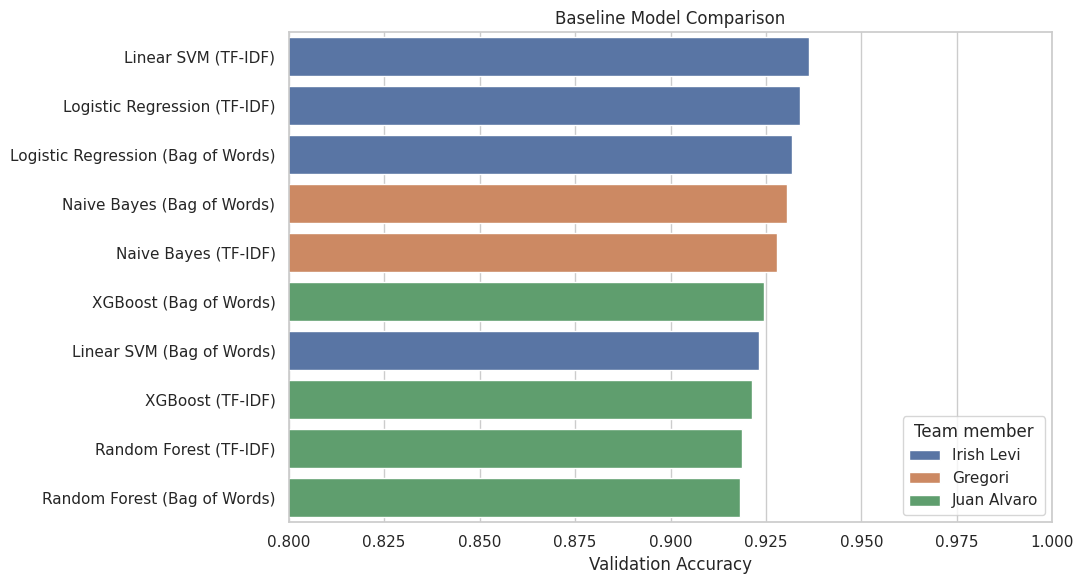

In [36]:
print("Combined baseline model comparison:")
display(baseline_results_df)

best_baseline = baseline_results_df.iloc[0]
print("\nBest baseline model:")
print(f"{best_baseline['Model']} + {best_baseline['Vectorizer']}")
print(f"Validation accuracy: {best_baseline['Validation Accuracy']:.4f}")

plt.figure(figsize=(11, 6))
plot_df = baseline_results_df.copy()
plot_df["Model + Vectorizer"] = plot_df["Model"] + " (" + plot_df["Vectorizer"] + ")"

sns.barplot(
    data=plot_df,
    y="Model + Vectorizer",
    x="Validation Accuracy",
    hue="Member",
    dodge=False,
)

plt.xlim(0.80, 1.00)
plt.title("Baseline Model Comparison")
plt.xlabel("Validation Accuracy")
plt.ylabel("")
plt.legend(title="Team member", loc="lower right")
plt.tight_layout()
plt.savefig("combined_baseline_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


The graph makes the result easier to see. The strongest models are the linear ones with TF-IDF, so for this dataset a simpler model seems better than a heavier tree model.


## 9. Hyperparameter Tuning


In [37]:
tuning_experiments = [
    {
        "name": "Logistic Regression tuned",
        "member": "Irish Levi",
        "pipeline": Pipeline([
            ("vectorizer", TfidfVectorizer(
                max_features=50_000,
                ngram_range=(1, 2),
                sublinear_tf=True,
                min_df=2,
            )),
            ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "vectorizer__max_df": [0.5, 0.75, 0.9, 1.0],
            "clf__C": [0.1, 1.0, 5.0, 10.0],
        },
    },
    {
        "name": "Linear SVM tuned",
        "member": "Irish Levi",
        "pipeline": Pipeline([
            ("vectorizer", TfidfVectorizer(
                max_features=50_000,
                ngram_range=(1, 2),
                sublinear_tf=True,
                min_df=2,
            )),
            ("clf", LinearSVC(max_iter=5000, random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "vectorizer__max_df": [0.75, 0.9, 1.0],
            "clf__C": [0.5, 1.0, 2.0],
        },
    },
    {
        "name": "Naive Bayes tuned",
        "member": "Gregori",
        "pipeline": Pipeline([
            ("vectorizer", CountVectorizer(
                max_features=50_000,
                ngram_range=(1, 2),
                min_df=2,
            )),
            ("clf", MultinomialNB()),
        ]),
        "param_grid": {
            "vectorizer__max_df": [0.5, 0.75, 0.9, 1.0],
            "clf__alpha": [0.01, 0.1, 0.5, 1.0],
        },
    },
]

if HAS_XGBOOST and RUN_EXPENSIVE_XGB_GRID:
    tuning_experiments.append(
        {
            "name": "XGBoost tuned",
            "member": "Juan Alvaro",
            "pipeline": Pipeline([
                ("vectorizer", CountVectorizer(
                    max_features=50_000,
                    ngram_range=(1, 2),
                    min_df=3,
                    binary=True,
                )),
                ("clf", XGBClassifier(
                    n_estimators=XGB_TUNING_ESTIMATORS,
                    tree_method="hist",
                    eval_metric="logloss",
                    verbosity=0,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "param_grid": {
                "vectorizer__max_df": [0.8, 0.9],
                "clf__learning_rate": [0.05, 0.1],
                "clf__max_depth": [6, 8],
            },
        }
    )

tuning_records = []
best_tuned_pipelines = {}

for exp in tuning_experiments:
    print(f"\nRunning GridSearchCV for: {exp['name']}")
    grid = GridSearchCV(
        estimator=exp["pipeline"],
        param_grid=exp["param_grid"],
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
        verbose=0,
    )

    grid.fit(X_train, y_train)

    val_preds = grid.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)

    best_tuned_pipelines[exp["name"]] = grid.best_estimator_

    tuning_records.append({
        "Member": exp["member"],
        "Model": exp["name"],
        "Vectorizer": "Pipeline",
        "Best CV Accuracy": grid.best_score_,
        "Validation Accuracy": val_acc,
        "Best Parameters": grid.best_params_,
        "Pipeline Key": exp["name"],
    })

    print(f"Best CV accuracy       : {grid.best_score_:.4f}")
    print(f"Validation accuracy    : {val_acc:.4f}")
    print(f"Best parameters        : {grid.best_params_}")

tuning_results_df = (
    pd.DataFrame(tuning_records)
    .sort_values("Validation Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(tuning_results_df)



Running GridSearchCV for: Logistic Regression tuned
Best CV accuracy       : 0.9311
Validation accuracy    : 0.9340
Best parameters        : {'clf__C': 5.0, 'vectorizer__max_df': 0.5}

Running GridSearchCV for: Linear SVM tuned
Best CV accuracy       : 0.9313
Validation accuracy    : 0.9359
Best parameters        : {'clf__C': 0.5, 'vectorizer__max_df': 0.75}

Running GridSearchCV for: Naive Bayes tuned
Best CV accuracy       : 0.9267
Validation accuracy    : 0.9306
Best parameters        : {'clf__alpha': 0.1, 'vectorizer__max_df': 0.5}


,Member,Model,Vectorizer,Best CV Accuracy,Validation Accuracy,Best Parameters,Pipeline Key
0,Irish Levi,Linear SVM tuned,Pipeline,0.931330,0.935880,"{'clf__C': 0.5, 'vectorizer__max_df': 0.75}",Linear SVM tuned
1,Irish Levi,Logistic Regression tuned,Pipeline,0.931136,0.934016,"{'clf__C': 5.0, 'vectorizer__max_df': 0.5}",Logistic Regression tuned
2,Gregori,Naive Bayes tuned,Pipeline,0.926711,0.930601,"{'clf__alpha': 0.1, 'vectorizer__max_df': 0.5}",Naive Bayes tuned


The tuning improved some settings but did not really change the winner. Linear SVM stayed at the top, which tells us that the baseline was already quite strong.


## 10. Final Best Model Selection


In [38]:
baseline_for_final = baseline_results_df.copy()
baseline_for_final["Type"] = "Baseline"
baseline_for_final["Best CV Accuracy"] = np.nan
baseline_for_final["Best Parameters"] = ""

tuned_for_final = tuning_results_df.copy()
tuned_for_final["Type"] = "Tuned"

final_comparison_df = pd.concat(
    [
        baseline_for_final[
            ["Type", "Member", "Model", "Vectorizer", "Validation Accuracy", "Best CV Accuracy", "Best Parameters", "Pipeline Key"]
        ],
        tuned_for_final[
            ["Type", "Member", "Model", "Vectorizer", "Validation Accuracy", "Best CV Accuracy", "Best Parameters", "Pipeline Key"]
        ],
    ],
    ignore_index=True,
).sort_values("Validation Accuracy", ascending=False).reset_index(drop=True)

display(final_comparison_df)

winner = final_comparison_df.iloc[0]
winner_key = winner["Pipeline Key"]

if winner["Type"] == "Baseline":
    final_best_pipeline = fitted_pipelines[winner_key]
else:
    final_best_pipeline = best_tuned_pipelines[winner_key]

print("Final selected model:")
print(f"Type       : {winner['Type']}")
print(f"Member     : {winner['Member']}")
print(f"Model      : {winner['Model']}")
print(f"Vectorizer : {winner['Vectorizer']}")
print(f"Validation accuracy: {winner['Validation Accuracy']:.4f}")


,Type,Member,Model,Vectorizer,Validation Accuracy,Best CV Accuracy,Best Parameters,Pipeline Key
0,Baseline,Irish Levi,Linear SVM,TF-IDF,0.936190,NaN,,Linear SVM | TF-IDF
1,Tuned,Irish Levi,Linear SVM tuned,Pipeline,0.935880,0.931330,"{'clf__C': 0.5, 'vectorizer__max_df': 0.75}",Linear SVM tuned
2,Baseline,Irish Levi,Logistic Regression,TF-IDF,0.934016,NaN,,Logistic Regression | TF-IDF
3,Tuned,Irish Levi,Logistic Regression tuned,Pipeline,0.934016,0.931136,"{'clf__C': 5.0, 'vectorizer__max_df': 0.5}",Logistic Regression tuned
4,Baseline,Irish Levi,Logistic Regression,Bag of Words,0.931843,NaN,,Logistic Regression | Bag of Words
5,Tuned,Gregori,Naive Bayes tuned,Pipeline,0.930601,0.926711,"{'clf__alpha': 0.1, 'vectorizer__max_df': 0.5}",Naive Bayes tuned
6,Baseline,Gregori,Naive Bayes,Bag of Words,0.930601,NaN,,Naive Bayes | Bag of Words
7,Baseline,Gregori,Naive Bayes,TF-IDF,0.927806,NaN,,Naive Bayes | TF-IDF
8,Baseline,Juan Alvaro,XGBoost,Bag of Words,0.924391,NaN,,XGBoost | Bag of Words
9,Baseline,Irish Levi,Linear SVM,Bag of Words,0.923304,NaN,,Linear SVM | Bag of Words


Final selected model:
Type       : Baseline
Member     : Irish Levi
Model      : Linear SVM
Vectorizer : TF-IDF
Validation accuracy: 0.9362


After putting the baseline and tuned models together, the selected final model is Linear SVM with TF-IDF. We choose it because it gives the highest validation accuracy in our comparison.


## 11. Detailed Evaluation of the Final Model


=== Final Model – Validation Report ===
              precision    recall  f1-score   support

    Fake (0)       0.94      0.93      0.94      3204
    Real (1)       0.93      0.94      0.94      3237

    accuracy                           0.94      6441
   macro avg       0.94      0.94      0.94      6441
weighted avg       0.94      0.94      0.94      6441



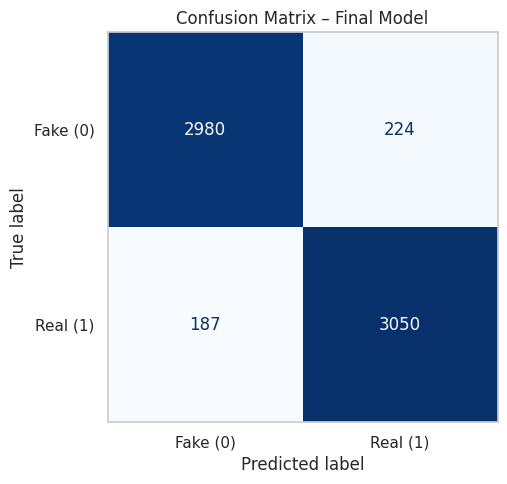

In [39]:
final_val_preds = final_best_pipeline.predict(X_val)

print("=== Final Model – Validation Report ===")
print(classification_report(y_val, final_val_preds, target_names=["Fake (0)", "Real (1)"]))

cm = confusion_matrix(y_val, final_val_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake (0)", "Real (1)"],
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix – Final Model")
ax.grid(False)
plt.tight_layout()
plt.savefig("final_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


The final report is balanced for both classes. Precision, recall and f1-score are all around 0.94, so the model is not only good for fake news or only for real news. It is working well on both labels.


## 12. Cross-Validation of the Final Model


In [40]:
cv_pipeline = clone(final_best_pipeline)

cv_scores = cross_val_score(
    cv_pipeline,
    X_full,
    y_full,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

print("5-fold CV accuracy scores:", cv_scores.round(4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-fold CV accuracy scores: [0.889  0.9107 0.8776 0.9214 0.9179]
Mean CV accuracy: 0.9033 ± 0.0171


The cross-validation score is lower than the single validation split, around 90.3 percent on average. This probably means the model is still good, but the exact score depends a bit on how the data is split.


## 13. Feature Interpretation


Top features pushing toward REAL (1):
factbox                        +3.2903
say                            +2.7012
urg                            +2.1541
seek                           +2.1065
china                          +2.1041
probe                          +1.9786
uk                             +1.9315
tillerson                      +1.9229
zimbabw                        +1.8801
senat                          +1.8463
exclus                         +1.7782
sourc                          +1.7596
role                           +1.7581
boost                          +1.7380
spokesman                      +1.7208
hous                           +1.7118
japan                          +1.7052
bali                           +1.6990
jerusalem                      +1.6930
sanction                       +1.6900

Top features pushing toward FAKE (0):
video                          -7.6087
gop                            -4.5158
hillari                        -4.4398
break                     

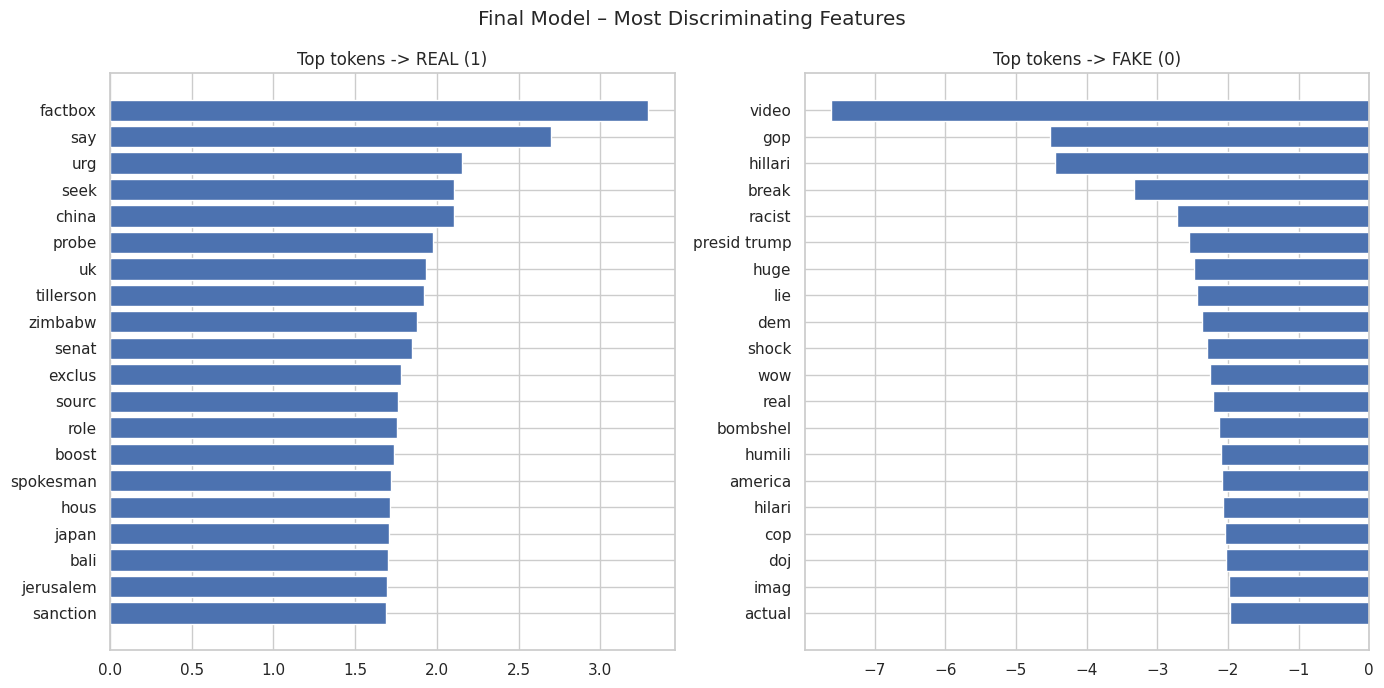

In [41]:
def extract_pipeline_steps(pipe):
    vectorizer = None
    classifier = None

    for step_name, step in pipe.named_steps.items():
        if isinstance(step, (CountVectorizer, TfidfVectorizer)):
            vectorizer = step
        else:
            classifier = step

    return vectorizer, classifier

vectorizer, classifier = extract_pipeline_steps(final_best_pipeline)

feature_names = vectorizer.get_feature_names_out()
top_n = 20

if hasattr(classifier, "coef_"):
    coef = classifier.coef_.ravel()

    top_real = np.argsort(coef)[-top_n:][::-1]
    top_fake = np.argsort(coef)[:top_n]

    print("Top features pushing toward REAL (1):")
    for idx in top_real:
        print(f"{feature_names[idx]:<30} {coef[idx]:+.4f}")

    print("\nTop features pushing toward FAKE (0):")
    for idx in top_fake:
        print(f"{feature_names[idx]:<30} {coef[idx]:+.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].barh(feature_names[top_real], coef[top_real])
    axes[0].set_title("Top tokens -> REAL (1)")
    axes[0].invert_yaxis()

    axes[1].barh(feature_names[top_fake], coef[top_fake])
    axes[1].set_title("Top tokens -> FAKE (0)")
    axes[1].invert_yaxis()

    plt.suptitle("Final Model – Most Discriminating Features")
    plt.tight_layout()
    plt.savefig("final_linear_top_features.png", dpi=120, bbox_inches="tight")
    plt.show()

elif hasattr(classifier, "feature_log_prob_"):
    log_prob_fake = classifier.feature_log_prob_[0]
    log_prob_real = classifier.feature_log_prob_[1]
    score = log_prob_real - log_prob_fake

    top_real = np.argsort(score)[-top_n:][::-1]
    top_fake = np.argsort(score)[:top_n]

    print("Top features pushing toward REAL (1):")
    for idx in top_real:
        print(f"{feature_names[idx]:<30} {score[idx]:+.4f}")

    print("\nTop features pushing toward FAKE (0):")
    for idx in top_fake:
        print(f"{feature_names[idx]:<30} {score[idx]:+.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].barh(feature_names[top_real], score[top_real])
    axes[0].set_title("Top tokens -> REAL (1)")
    axes[0].invert_yaxis()

    axes[1].barh(feature_names[top_fake], score[top_fake])
    axes[1].set_title("Top tokens -> FAKE (0)")
    axes[1].invert_yaxis()

    plt.suptitle("Naive Bayes – Log Probability Difference")
    plt.tight_layout()
    plt.savefig("final_nb_top_features.png", dpi=120, bbox_inches="tight")
    plt.show()

elif hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
    top_idx = np.argsort(importances)[-top_n:][::-1]

    print("Top important features:")
    for idx in top_idx:
        print(f"{feature_names[idx]:<30} {importances[idx]:.6f}")

    plt.figure(figsize=(10, 7))
    plt.barh(feature_names[top_idx], importances[top_idx])
    plt.title("Final Tree-Based Model – Top Feature Importances")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("final_tree_top_features.png", dpi=120, bbox_inches="tight")
    plt.show()

else:
    print("This classifier does not expose coefficients, log probabilities, or feature importances.")


The most important words also make sense. Some words are more connected with real news style, while words like video, gop, hillari or breaking appear more on the fake side. This helps us understand that the model is learning patterns from the language.


## 14. Error Analysis


In [42]:
errors_df = val_part.copy()
errors_df["predicted_label"] = final_val_preds
errors_df["correct"] = errors_df["label"] == errors_df["predicted_label"]

wrong_predictions = errors_df[~errors_df["correct"]].copy()

print(f"Validation errors: {len(wrong_predictions):,} out of {len(errors_df):,}")
print(f"Validation error rate: {1 - accuracy_score(y_val, final_val_preds):.4f}")

display(
    wrong_predictions[["text", "clean_text", "label", "predicted_label"]]
    .head(15)
    .rename(columns={
        "label": "true_label",
    })
)


Validation errors: 411 out of 6,441
Validation error rate: 0.0638


,text,clean_text,true_label,predicted_label
7860,illinois republicans attack single mothers,illinoi republican attack singl mother,0,1
24633,for islamophobia\ttake two of these and call a...,islamophobia take two call muslim morn,1,0
3436,texas pastor angers parents,texa pastor anger parent,0,1
4892,these 2 orlando hospitals just saved pulse nig...,orlando hospit save puls nightclub shoot victi...,0,1
22479,republicans make repealing obamacare 'first or...,republican make repeal obamacar first order busi,1,0
12144,trump poised to reverse obama‚s politicized ‚g...,trump pois revers obama politic global warm po...,0,1
24520,dispatch from inside the conventions,dispatch insid convent,1,0
2768,trump executive order mandates two regulation ...,trump execut order mandat two regul cut everi ...,0,1
22366,cnn says its reports on trump intel documents ...,cnn say report trump intel document differ buzzfe,1,0
3665,meet the republicans who may actually help dem...,meet republican may actual help democrat contr...,0,1


There are 411 wrong predictions in the validation set. Looking at them is useful because many headlines are short or ambiguous, so even for a person some of them are not obvious without more context.


## 15. Retrain on the Full Training Dataset


In [43]:
final_model_full = clone(final_best_pipeline)
final_model_full.fit(X_full, y_full)

print("Final model retrained on the full cleaned training dataset.")
print(f"Training rows used: {len(X_full):,}")


Final model retrained on the full cleaned training dataset.
Training rows used: 32,202


Once the best model is chosen, we train it again using all the labelled training data. This gives the model more examples before making the final predictions on the test file.


## 16. Generate Predictions for the Test File


In [44]:
X_test = test_clean_df["clean_text"].fillna("")

test_predictions = final_model_full.predict(X_test).astype(int)

print("Prediction distribution in test set:")
print(pd.Series(test_predictions).value_counts().sort_index().rename({0: "Fake (0)", 1: "Real (1)"}))

predicted_test_df = test_clean_df.copy()
predicted_test_df["label"] = test_predictions

display(predicted_test_df.head())


Prediction distribution in test set:
Fake (0)    4796
Real (1)    5188
Name: count, dtype: int64


,label,text,clean_text
0,0,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrest assault weapon
1,0,wow! chicago protester caught on camera admits...,wow chicago protest caught camera admit violen...
2,0,germany's fdp look to fill schaeuble's big shoes,germani fdp look fill schaeubl big shoe
3,0,mi school sends welcome back packet warning ki...,mi school send welcom back packet warn kid wea...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...,seek massiv aid boost amid rohingya emerg with...


The predictions on the test set are also quite balanced, with a bit more real news than fake news. The important part is that every test row now has a predicted label instead of the placeholder value.


## 17. Save the Final Prediction File


In [ ]:
OUTPUT_PATH = "outputs_predictions.csv"

predicted_test_df[["label", "text"]].to_csv(
    OUTPUT_PATH,
    sep="\t",
    header=False,
    index=False,
    encoding="utf-8",
)

print(f"Saved final prediction file: {OUTPUT_PATH}")
print(f"Rows saved: {len(predicted_test_df):,}")

display(pd.read_csv(OUTPUT_PATH, sep="\t", header=None, names=["label", "text"]).head())


This is the final file needed for delivery. It keeps the same basic format as the original test file, but the first column now contains only 0 or 1.


## 18. Final Conclusion

The final model we selected was Linear SVM with TF-IDF. It was the best option in our validation comparison and it also gave balanced results for fake and real news.

The file outputs_predictions.csv is the final deliverable. It has the same rows as the test file and the first column has been replaced with our predicted labels.


## 19. Additional Transformer Model: ELECTRA Small

This extra section adds the Transformer model trained in the separate ELECTRA files.

The model is valid to include because it uses the same task, the same binary labels, and a validation split from the same training dataset. Its reported validation performance is much higher than the classical TF-IDF models:

| Model | Validation accuracy | Weighted F1-score | Validation rows |
|---|---:|---:|---:|
| Linear SVM + TF-IDF | 0.9362 | around 0.94 | 6,441 |
| ELECTRA Small Transformer | 0.9778 | 0.9778 | 6,441 |

Important correction: in this dataset, **0 = Fake** and **1 = Real**. One comment in the original ELECTRA notebook described the labels the other way around, but the predictions themselves follow the same meaning used in this final notebook.

In [45]:
# Summary of the ELECTRA model trained in the separate notebook
# These numbers come from the executed ELECTRA training output.

electra_results_df = pd.DataFrame([
    {
        "Type": "Transformer",
        "Member": "Juan Alvaro",
        "Model": "ELECTRA Small",
        "Vectorizer": "ELECTRA tokenizer",
        "Validation Accuracy": 0.977798,
        "Weighted F1": 0.977798,
        "Validation Rows": 6441,
        "Checkpoint": "google/electra-small-discriminator",
    }
])

display(electra_results_df)

# Add ELECTRA to the existing final comparison table if that table already exists.
if "final_comparison_df" in globals():
    classical_plus_transformer_df = final_comparison_df.copy()
    classical_plus_transformer_df["Weighted F1"] = np.nan
    classical_plus_transformer_df["Validation Rows"] = len(y_val) if "y_val" in globals() else np.nan
    classical_plus_transformer_df["Checkpoint"] = ""

    electra_for_comparison = electra_results_df.copy()
    electra_for_comparison["Best CV Accuracy"] = np.nan
    electra_for_comparison["Best Parameters"] = "Fine-tuned for 3 epochs, learning_rate=5e-5, max_length=128"
    electra_for_comparison["Pipeline Key"] = "ELECTRA Small Transformer"

    classical_plus_transformer_df = pd.concat(
        [classical_plus_transformer_df, electra_for_comparison[classical_plus_transformer_df.columns]],
        ignore_index=True,
    ).sort_values("Validation Accuracy", ascending=False).reset_index(drop=True)

    display(classical_plus_transformer_df)

    print("Best model after adding Transformer:")
    print(classical_plus_transformer_df.loc[0, "Model"])
    print(f"Validation accuracy: {classical_plus_transformer_df.loc[0, 'Validation Accuracy']:.4f}")
else:
    print("final_comparison_df was not found. Run the previous comparison cells first if you want the full table.")

,Type,Member,Model,Vectorizer,Validation Accuracy,Weighted F1,Validation Rows,Checkpoint
0,Transformer,Juan Alvaro,ELECTRA Small,ELECTRA tokenizer,0.977798,0.977798,6441,google/electra-small-discriminator


,Type,Member,Model,Vectorizer,Validation Accuracy,Best CV Accuracy,Best Parameters,Pipeline Key,Weighted F1,Validation Rows,Checkpoint
0,Transformer,Juan Alvaro,ELECTRA Small,ELECTRA tokenizer,0.977798,NaN,"Fine-tuned for 3 epochs, learning_rate=5e-5, m...",ELECTRA Small Transformer,0.977798,6441,google/electra-small-discriminator
1,Baseline,Irish Levi,Linear SVM,TF-IDF,0.936190,NaN,,Linear SVM | TF-IDF,NaN,6441,
2,Tuned,Irish Levi,Linear SVM tuned,Pipeline,0.935880,0.931330,"{'clf__C': 0.5, 'vectorizer__max_df': 0.75}",Linear SVM tuned,NaN,6441,
3,Baseline,Irish Levi,Logistic Regression,TF-IDF,0.934016,NaN,,Logistic Regression | TF-IDF,NaN,6441,
4,Tuned,Irish Levi,Logistic Regression tuned,Pipeline,0.934016,0.931136,"{'clf__C': 5.0, 'vectorizer__max_df': 0.5}",Logistic Regression tuned,NaN,6441,
5,Baseline,Irish Levi,Logistic Regression,Bag of Words,0.931843,NaN,,Logistic Regression | Bag of Words,NaN,6441,
6,Tuned,Gregori,Naive Bayes tuned,Pipeline,0.930601,0.926711,"{'clf__alpha': 0.1, 'vectorizer__max_df': 0.5}",Naive Bayes tuned,NaN,6441,
7,Baseline,Gregori,Naive Bayes,Bag of Words,0.930601,NaN,,Naive Bayes | Bag of Words,NaN,6441,
8,Baseline,Gregori,Naive Bayes,TF-IDF,0.927806,NaN,,Naive Bayes | TF-IDF,NaN,6441,
9,Baseline,Juan Alvaro,XGBoost,Bag of Words,0.924391,NaN,,XGBoost | Bag of Words,NaN,6441,


Best model after adding Transformer:
ELECTRA Small
Validation accuracy: 0.9778


### Why ELECTRA is different from the previous models

The previous models used **Bag of Words** or **TF-IDF**. Those methods convert text into word-count features, but they do not really understand the order or context of the sentence.

ELECTRA is a **Transformer** model. Instead of only counting words, it reads the headline as a sequence and creates contextual representations. This usually works better for language tasks because the model can use word meaning, word order and context.

For this project, the classical winner was still useful because it is simpler, faster and easier to explain. But after adding the Transformer model, ELECTRA becomes the strongest model by validation accuracy.

### Optional setup cell for running ELECTRA

The next cell is only needed if the notebook is being run in a fresh environment, especially in Google Colab. Transformer training is much heavier than the previous models, so using a GPU is strongly recommended.

In [46]:
# Uncomment and run this cell only if the required libraries are missing.
# In Google Colab this is usually safe to run.

# %pip install -q "transformers[torch]" datasets accelerate scikit-learn pandas

### Reproducible ELECTRA training code

This cell contains the corrected version of the ELECTRA training workflow. It is disabled by default so that running the full notebook does not accidentally start a long GPU training job.

To retrain the Transformer model, change `RUN_ELECTRA_TRAINING = False` to `True`.

In [47]:
RUN_ELECTRA_TRAINING = False

if not RUN_ELECTRA_TRAINING:
    print("ELECTRA training is disabled. Set RUN_ELECTRA_TRAINING = True to retrain the Transformer model.")
else:
    import torch
    from datasets import Dataset
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

    MODEL_CKPT = "google/electra-small-discriminator"
    MAX_LENGTH = 128
    RANDOM_STATE = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # Use the already loaded train_df if the previous cells have been executed.
    # Otherwise, load the original training file from the same candidate paths used earlier.
    if "train_df" in globals():
        electra_df = train_df[["label", "text"]].copy()
    else:
        train_path = find_existing_path(TRAIN_CANDIDATES)
        electra_df = pd.read_csv(train_path, sep="\t", header=None, names=["label", "text"])

    # Keep the same label meaning used in the whole notebook:
    # 0 = Fake, 1 = Real
    electra_df["label"] = (
        electra_df["label"]
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
        .astype(int)
    )

    electra_df = electra_df.drop_duplicates(subset=["text"], keep="first")
    electra_df = electra_df.dropna(subset=["text", "label"])
    electra_df["text"] = electra_df["text"].astype(str)

    print("Final class distribution for ELECTRA:")
    print(electra_df["label"].value_counts().sort_index().rename({0: "Fake (0)", 1: "Real (1)"}))

    electra_train_df, electra_val_df = train_test_split(
        electra_df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=electra_df["label"],
    )

    train_dataset = Dataset.from_pandas(electra_train_df[["text", "label"]].reset_index(drop=True))
    val_dataset = Dataset.from_pandas(electra_val_df[["text", "label"]].reset_index(drop=True))

    tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        )

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_val = val_dataset.map(tokenize_function, batched=True)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(labels, predictions),
            "f1": f1_score(labels, predictions, average="weighted"),
        }

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_CKPT, num_labels=2)
    model.config.problem_type = "single_label_classification"

    use_bf16 = bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported())

    training_args_base = dict(
        output_dir="electra_small_fake_news",
        num_train_epochs=3,
        learning_rate=5e-5,
        per_device_train_batch_size=64 if torch.cuda.is_available() else 8,
        per_device_eval_batch_size=64 if torch.cuda.is_available() else 8,
        bf16=use_bf16,
        weight_decay=0.01,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=100,
        report_to="none",
    )

    # Different Transformers versions use different argument names.
    try:
        training_args = TrainingArguments(**training_args_base, eval_strategy="epoch")
    except TypeError:
        training_args = TrainingArguments(**training_args_base, evaluation_strategy="epoch")

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
    )

    print(f"Starting ELECTRA training on {DEVICE.upper()}...")
    trainer.train()

    print("\nGenerating final validation report...")
    predictions_output = trainer.predict(tokenized_val)
    electra_val_preds = np.argmax(predictions_output.predictions, axis=-1)
    electra_y_true = predictions_output.label_ids

    electra_accuracy = accuracy_score(electra_y_true, electra_val_preds)
    electra_f1 = f1_score(electra_y_true, electra_val_preds, average="weighted")

    print(f"ELECTRA validation accuracy: {electra_accuracy:.4f}")
    print(f"ELECTRA weighted F1-score : {electra_f1:.4f}")
    print(classification_report(electra_y_true, electra_val_preds, target_names=["Fake (0)", "Real (1)"]))

    cm = confusion_matrix(electra_y_true, electra_val_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake (0)", "Real (1)"])
    disp.plot(colorbar=False)
    plt.title("Confusion Matrix – ELECTRA Small")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

ELECTRA training is disabled. Set RUN_ELECTRA_TRAINING = True to retrain the Transformer model.


### Create a corrected ELECTRA submission file

The generated ELECTRA prediction file from the separate notebook contains the columns `text` and `transformer_pred`. That proves inference was done, but for this project the final delivery format should match the original testing file: first column = predicted label, second column = text.

The next cell converts the existing ELECTRA predictions into the same format used by the rest of this final notebook.

In [48]:
# This cell converts an already generated ELECTRA prediction file into the final project format.
# Expected input columns: text, transformer_pred
# Output format: label, text   with tab separator, no header, no index

ELECTRA_PREDICTION_CANDIDATES = [
    "JA_electra_SUBMISSION.csv",
    "Transformers/ELECTRA_small/JA_electra_SUBMISSION.csv",
    "/content/drive/MyDrive/project-3-nlp/Transformers/ELECTRA_small/JA_electra_SUBMISSION.csv",
]

def find_optional_path(candidates):
    for candidate in candidates:
        if Path(candidate).exists():
            return candidate
    return None

electra_prediction_path = find_optional_path(ELECTRA_PREDICTION_CANDIDATES)

if electra_prediction_path is None:
    print("No pre-generated ELECTRA prediction file was found.")
    print("If you retrain ELECTRA in the previous cell, you can generate predictions directly from the trained trainer object.")
else:
    electra_submission_raw = pd.read_csv(electra_prediction_path)

    if "transformer_pred" not in electra_submission_raw.columns:
        raise ValueError("The ELECTRA file must contain a column called 'transformer_pred'.")

    electra_labels = electra_submission_raw["transformer_pred"].astype(int)

    if not electra_labels.isin([0, 1]).all():
        raise ValueError("ELECTRA predictions must contain only 0 and 1.")

    # Prefer the original test text from test_df if available, because that preserves the exact project order and format.
    if "test_df" in globals() and len(test_df) == len(electra_submission_raw):
        electra_final_output_df = test_df[["text"]].copy()
    else:
        electra_final_output_df = electra_submission_raw[["text"]].copy()

    electra_final_output_df.insert(0, "label", electra_labels.values)

    ELECTRA_OUTPUT_PATH = "outputs_predictions_electra.csv"
    electra_final_output_df[["label", "text"]].to_csv(
        ELECTRA_OUTPUT_PATH,
        sep="\t",
        header=False,
        index=False,
        encoding="utf-8",
    )

    print(f"Saved corrected ELECTRA prediction file: {ELECTRA_OUTPUT_PATH}")
    print(f"Rows saved: {len(electra_final_output_df):,}")
    print("Prediction distribution:")
    print(electra_final_output_df["label"].value_counts().sort_index().rename({0: "Fake (0)", 1: "Real (1)"}))

    display(electra_final_output_df.head())

No pre-generated ELECTRA prediction file was found.
If you retrain ELECTRA in the previous cell, you can generate predictions directly from the trained trainer object.


## 20. Updated Final Conclusion After Adding ELECTRA

The original final model in this notebook was **Linear SVM with TF-IDF**, because it was the best classical machine learning model in our comparison.

After adding the Transformer experiment, the strongest model becomes **ELECTRA Small**, with a reported validation accuracy of **97.78%** and a weighted F1-score of **97.78%**.

So the final interpretation is:

- **Best classical model:** Linear SVM + TF-IDF.
- **Best overall model:** ELECTRA Small Transformer.
- **Why ELECTRA wins:** it understands the headline through contextual embeddings instead of only counting words.
- **Practical note:** ELECTRA is more accurate, but it is also heavier, slower and needs a stronger environment such as Google Colab with GPU.

For the final delivery, use `outputs_predictions_electra.csv` if the project allows the Transformer model as the final submission. Otherwise, use the previous `outputs_predictions.csv` generated by the Linear SVM model.